# Análsis cuestionario Lookiero

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

In [2]:
lookiero_palette = ['#F3A2AD', '#CA6573', '#A23645', '#791422', '#51000B']
sns.set_theme(style="whitegrid")
sns.set_palette(lookiero_palette)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'

ideal_path = [
    'quiz_leisure', 'quiz_work', 'quiz_fit', 'quiz_highlight', 'quiz_bodyShape',
    'quiz_eyes', 'quiz_hair', 'quiz_sizes', 'quiz_measurements', 
    'quiz_focus', 'quiz_adventurous', 'quiz_styles', 'quiz_prices', 
    'quiz_avoid', 'quiz_footwear', 'quiz_you', 'quiz_photos', 'quiz_social', 
    'quiz_signUp'
]
step_rank = {section: i + 1 for i, section in enumerate(ideal_path)}

df = pd.read_csv('Datos/Originales/Datos UX/page_views_2.csv', sep=';')
df['event_timestamp_'] = pd.to_datetime(df['event_timestamp_'])
df = df.sort_values(['user_id', 'event_timestamp_']).reset_index(drop=True)

TIMEOUT_LIMIT = 20 * 60 

df['prev_timestamp'] = df.groupby('user_id')['event_timestamp_'].shift(1)
df['time_since_prev'] = (df['event_timestamp_'] - df['prev_timestamp']).dt.total_seconds()

df['is_new_session'] = (df['prev_timestamp'].isna()) | (df['time_since_prev'] > TIMEOUT_LIMIT)
df['session_rank'] = df.groupby('user_id')['is_new_session'].cumsum()
df['global_session_id'] = df['user_id'] + "_S" + df['session_rank'].astype(str)

df['next_timestamp'] = df.groupby('global_session_id')['event_timestamp_'].shift(-1)
df['time_on_page'] = (df['next_timestamp'] - df['event_timestamp_']).dt.total_seconds()

df['step_number'] = df['section'].map(step_rank)
df['prev_step_number'] = df.groupby('global_session_id')['step_number'].shift(1)
df['step_diff'] = df['step_number'] - df['prev_step_number']

df['is_skip'] = (df['step_diff'] > 1)     
df['is_backtrack'] = (df['step_diff'] < 0)  

user_summary = df.groupby('user_id').agg(
    total_sessions=('session_rank', 'max'),
    first_entry_point=('section', 'first'),
    final_section=('section', 'last')
).reset_index()

def define_status(row):
    converted = row['final_section'] == 'quiz_signUp'
    if converted:
        return 'Convertida (Recapturada)' if row['total_sessions'] > 1 else 'Convertida (Directa)'
    else:
        return 'Abandono Recurrente' if row['total_sessions'] > 1 else 'Abandono Temprano'

user_summary['user_status'] = user_summary.apply(define_status, axis=1)

user_summary

,user_id,total_sessions,first_entry_point,final_section,user_status
0,040e1e30c9ed4248bc9799a707e36d60,1,quiz_work,quiz_signUp,Convertida (Directa)
1,08524cc6b3544d65af7faa39e9abd3f2,2,quiz_leisure,quiz_signUp,Convertida (Recapturada)
2,0b9ab36679d64edbb7d6a830d103b91f,1,quiz_work,quiz_signUp,Convertida (Directa)
3,0c4e7af8218440eaa383bc6655712a55,1,quiz_leisure,quiz_leisure,Abandono Temprano
4,117c6171044e4fdf8cbd8c4dc6a59cb8,1,quiz_work,quiz_signUp,Convertida (Directa)
5,1285e4e59c0d43e4ac921cd9db535f0d,2,quiz_work,quiz_signUp,Convertida (Recapturada)
6,1932240bef894979be69257cc5431843,1,quiz_work,quiz_signUp,Convertida (Directa)
7,19322fed157c49c6b16e2d5cabeb9592,1,quiz_work,quiz_signUp,Convertida (Directa)
8,287cd4480785430b83bb19f93318a7b7,2,quiz_work,quiz_signUp,Convertida (Recapturada)
9,28afb6f2fecb45508fb35ed818927b57,1,quiz_work,quiz_signUp,Convertida (Directa)


#### Output de Diagnóstico (Validación)

In [3]:
print("--- 1. DIAGNÓSTICO DE VOLUMEN ---")
print(f"Usuarias Únicas: {df['user_id'].nunique()}")
print(f"Total Sesiones: {df['global_session_id'].nunique()}")
print(f"Eventos Totales: {len(df)}")

--- 1. DIAGNÓSTICO DE VOLUMEN ---
Usuarias Únicas: 41
Total Sesiones: 57
Eventos Totales: 794


In [4]:
print("\n--- 2. ANÁLISIS DE RECURRENCIA ---")
print(f"Max Sesiones por usuaria: {user_summary['total_sessions'].max()}")
print(f"Promedio Sesiones/Usuaria: {user_summary['total_sessions'].mean():.2f}")
print("Distribución de estatus de usuaria:")
print(user_summary['user_status'].value_counts())


--- 2. ANÁLISIS DE RECURRENCIA ---
Max Sesiones por usuaria: 4
Promedio Sesiones/Usuaria: 1.39
Distribución de estatus de usuaria:
user_status
Convertida (Directa)        24
Convertida (Recapturada)     8
Abandono Temprano            5
Abandono Recurrente          4
Name: count, dtype: int64


In [5]:
print("\n--- 3. ANÁLISIS DE ENTRADA ---")
print("Primera sección vista (Punto de Entrada):")
print(user_summary['first_entry_point'].value_counts().head(3))


--- 3. ANÁLISIS DE ENTRADA ---
Primera sección vista (Punto de Entrada):
first_entry_point
quiz_work       27
quiz_leisure    13
quiz_signUp      1
Name: count, dtype: int64


In [6]:
print("\n--- 4. INTEGRIDAD DEL FLUJO ---")
print(f"Saltos (Skips) detectados: {df['is_skip'].sum()}")
print(f"Retornos (Backtracks) detectados: {df['is_backtrack'].sum()}")


--- 4. INTEGRIDAD DEL FLUJO ---
Saltos (Skips) detectados: 12
Retornos (Backtracks) detectados: 51


### Funnel de alcance por sección
Identificar hasta dónde llegan las usuarias, sin asumir orden obligatorio ni causalidad.

C:\Users\gorja\AppData\Local\Temp\ipykernel_5528\2533589718.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


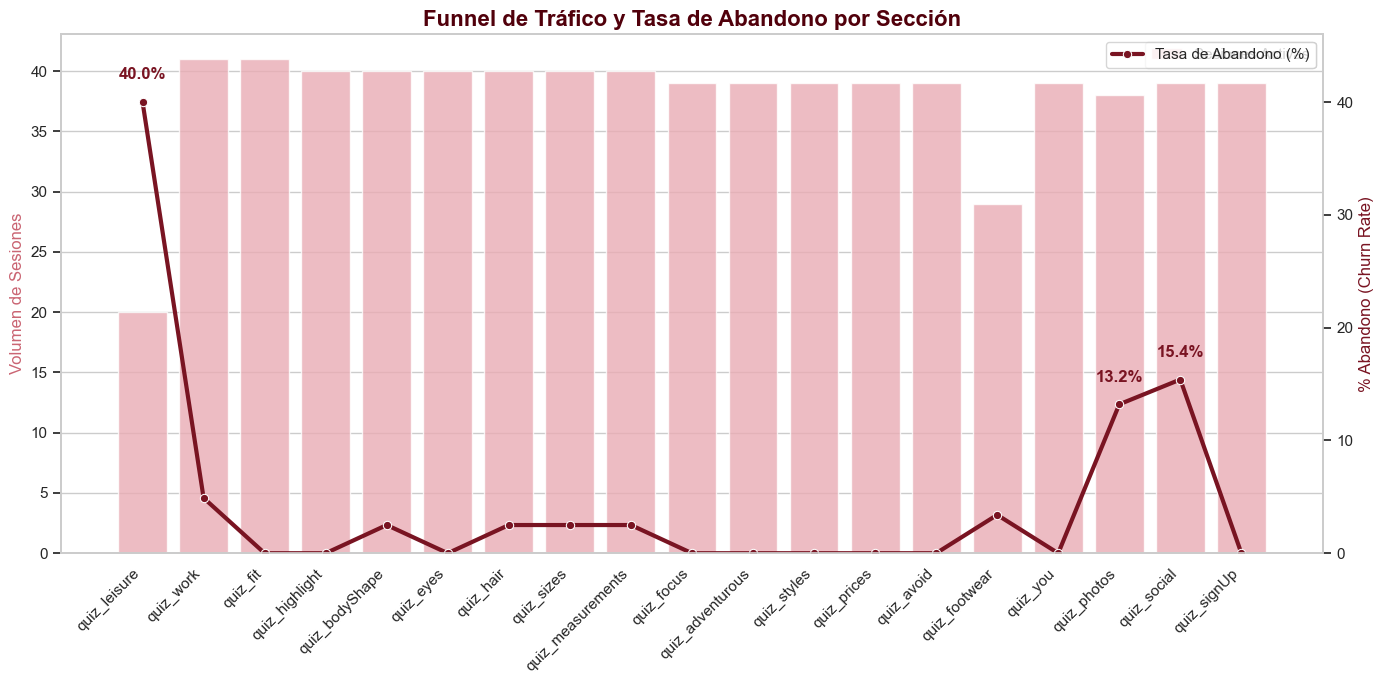

In [7]:
section_traffic = df.groupby('section')['global_session_id'].nunique().reset_index()
section_traffic.columns = ['section', 'unique_sessions']

session_endings = df.sort_values('event_timestamp_').groupby('global_session_id')['section'].last().reset_index()
dropoff_counts = session_endings['section'].value_counts().reset_index()
dropoff_counts.columns = ['section', 'dropoffs']

funnel_data = pd.DataFrame({'section': ideal_path})
funnel_data = funnel_data.merge(section_traffic, on='section', how='left').fillna(0)
funnel_data = funnel_data.merge(dropoff_counts, on='section', how='left').fillna(0)

funnel_data['churn_rate'] = (funnel_data['dropoffs'] / funnel_data['unique_sessions'] * 100).round(1)
funnel_data.loc[funnel_data['section'] == 'quiz_signUp', 'churn_rate'] = 0

fig, ax1 = plt.subplots(figsize=(14, 7))

sns.barplot(data=funnel_data, x='section', y='unique_sessions', 
            color='#F3A2AD', alpha=0.8, ax=ax1, label='Sesiones Activas')

ax2 = ax1.twinx()
sns.lineplot(data=funnel_data, x='section', y='churn_rate', 
             color='#791422', marker='o', linewidth=3, ax=ax2, label='Tasa de Abandono (%)')

ax1.set_title('Funnel de Tráfico y Tasa de Abandono por Sección', fontsize=16, fontweight='bold', color='#51000B')
ax1.set_xlabel('')
ax1.set_ylabel('Volumen de Sesiones', color='#CA6573')
ax2.set_ylabel('% Abandono (Churn Rate)', color='#791422')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax2.set_ylim(0, funnel_data['churn_rate'].max() * 1.15)
ax2.grid(False)

for idx, row in funnel_data.iterrows():
    if row['churn_rate'] > 10 and row['section'] != 'quiz_signUp':
        ax2.text(idx, row['churn_rate'] + 2, f"{row['churn_rate']}%", 
                 color='#791422', fontweight='bold', ha='center')

plt.tight_layout()
plt.show()

### Análisis de abandono por sección y sección inicial

In [8]:
last_section = (
    df.groupby('user_id')['section']
      .last()
      .reset_index(name='last_section')
)

first_section = (
    df.groupby('user_id')['section']
      .first()
      .reset_index(name='first_section')
)

user_flow = pd.merge(first_section, last_section, on='user_id')

abandonos = user_flow[user_flow['last_section'] != 'quiz_signUp']

abandono_por_seccion = (
    abandonos.groupby('last_section')
    .size()
    .sort_values(ascending=False)
    .reset_index(name='num_abandonos')
)

print("Abandonos por sección final:")
print(abandono_por_seccion)


Abandonos por sección final:
   last_section  num_abandonos
0  quiz_leisure              5
1   quiz_social              2
2      quiz_fit              1
3     quiz_work              1


In [9]:
entradas_validas = user_flow[
    user_flow['first_section'].isin(['quiz_leisure', 'quiz_work'])
]

abandono_por_entrada = (
    entradas_validas
    .assign(abandona=lambda x: x['last_section'] != 'quiz_signUp')
    .groupby('first_section')
    .agg(
        total_usuarias=('user_id', 'nunique'),
        abandonos=('abandona', 'sum')
    )
    .reset_index()
)

abandono_por_entrada['tasa_abandono'] = (
    abandono_por_entrada['abandonos'] /
    abandono_por_entrada['total_usuarias']
)

print("Abandono por sección inicial:")
print(abandono_por_entrada)

Abandono por sección inicial:
  first_section  total_usuarias  abandonos  tasa_abandono
0  quiz_leisure              13          7       0.538462
1     quiz_work              27          2       0.074074


C:\Users\gorja\AppData\Local\Temp\ipykernel_5528\3074511065.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\gorja\AppData\Local\Temp\ipykernel_5528\3074511065.py:2: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.barplot(


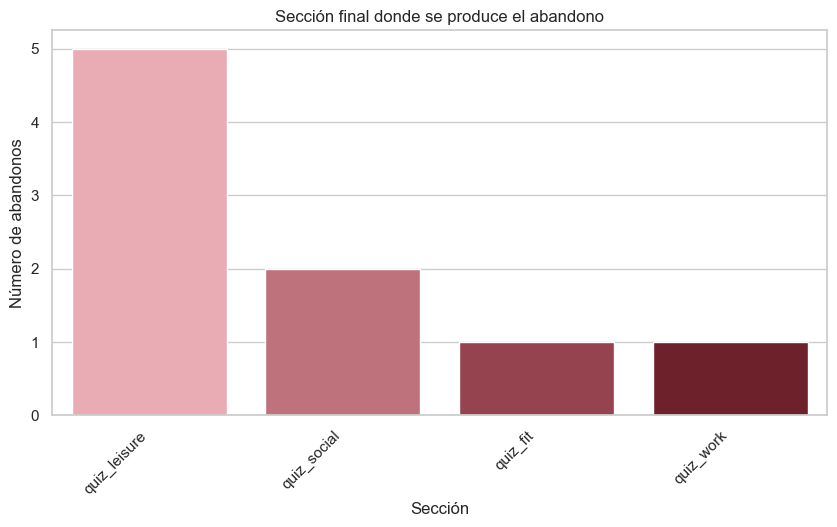

In [10]:
plt.figure(figsize=(10,5))
sns.barplot(
    x='last_section',
    y='num_abandonos',
    data=abandono_por_seccion,
    palette=lookiero_palette 
)
plt.xticks(rotation=45, ha='right')
plt.title('Sección final donde se produce el abandono')
plt.ylabel('Número de abandonos')
plt.xlabel('Sección')
plt.show()

C:\Users\gorja\AppData\Local\Temp\ipykernel_5528\1695063904.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\gorja\AppData\Local\Temp\ipykernel_5528\1695063904.py:4: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.barplot(


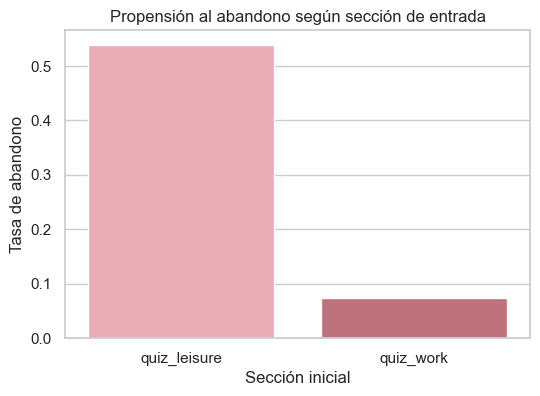

In [11]:
lookiero_palette = ['#F3A2AD', '#CA6573', '#A23645', '#791422', '#51000B']

plt.figure(figsize=(6,4))
sns.barplot(
    x='first_section',
    y='tasa_abandono',
    data=abandono_por_entrada,
    palette=lookiero_palette 
)
plt.ylabel('Tasa de abandono')
plt.xlabel('Sección inicial')
plt.title('Propensión al abandono según sección de entrada')
plt.show()

C:\Users\gorja\AppData\Local\Temp\ipykernel_5528\387372592.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=entry_counts.head(3), x='Section', y='Users', palette=lookiero_palette)
C:\Users\gorja\AppData\Local\Temp\ipykernel_5528\387372592.py:6: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  ax = sns.barplot(data=entry_counts.head(3), x='Section', y='Users', palette=lookiero_palette)


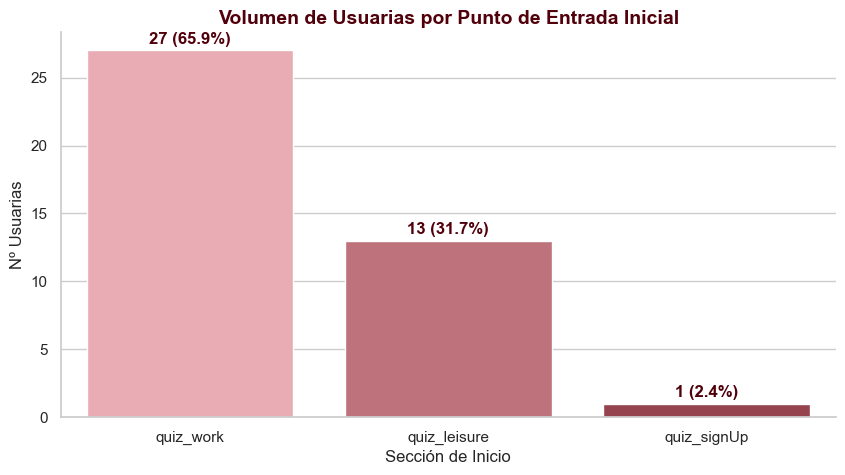

In [12]:
entry_counts = user_summary['first_entry_point'].value_counts().reset_index()
entry_counts.columns = ['Section', 'Users']
entry_counts['Percentage'] = (entry_counts['Users'] / entry_counts['Users'].sum() * 100).round(1)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=entry_counts.head(3), x='Section', y='Users', palette=lookiero_palette)

plt.title('Volumen de Usuarias por Punto de Entrada Inicial', fontsize=14, fontweight='bold', color='#51000B')
plt.xlabel('Sección de Inicio', fontsize=12)
plt.ylabel('Nº Usuarias', fontsize=12)

for i, p in enumerate(ax.patches):
    height = p.get_height()
    if i < len(entry_counts):
        pct = entry_counts.iloc[i]['Percentage']
        ax.text(p.get_x() + p.get_width()/2., height + 0.5, f'{int(height)} ({pct}%)', 
                ha="center", color='#51000B', fontweight='bold')

sns.despine()
plt.show()

### Tiempo entre secciones (UX real)

C:\Users\gorja\AppData\Local\Temp\ipykernel_5528\2105399645.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


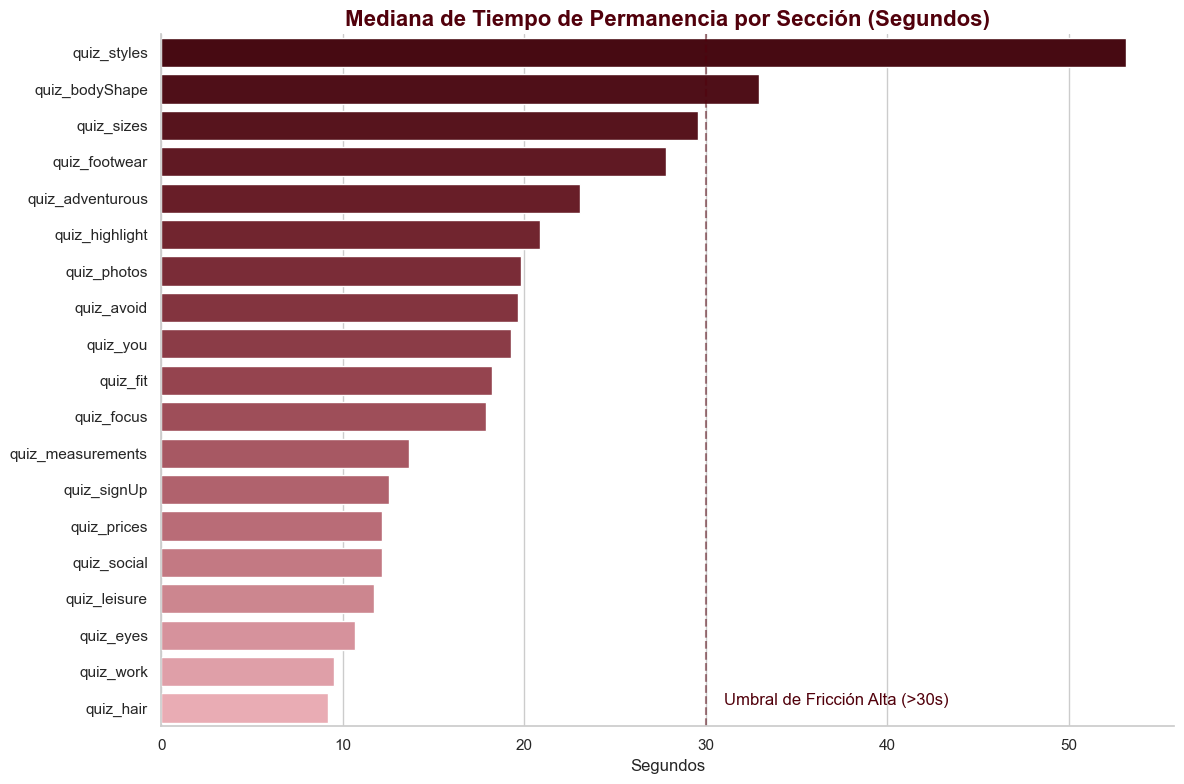

In [13]:
df_times = df[(df['time_on_page'] > 1) & (df['time_on_page'] < 300)].copy()

time_stats = df_times.groupby('section')['time_on_page'].median().reset_index()
time_stats = time_stats.sort_values('time_on_page', ascending=False)

lookiero_palette = ['#F3A2AD', '#CA6573', '#A23645', '#791422', '#51000B']

palette_reversed = lookiero_palette[::-1]

cmap = mcolors.LinearSegmentedColormap.from_list("lookiero_gradient", palette_reversed)

n_bars = len(time_stats)
gradient_colors = [cmap(i) for i in np.linspace(0, 1, n_bars)]

plt.figure(figsize=(12, 8))

sns.barplot(
    data=time_stats, 
    y='section', 
    x='time_on_page', 
    palette=gradient_colors
)

plt.title('Mediana de Tiempo de Permanencia por Sección (Segundos)', fontsize=16, fontweight='bold', color='#51000B')
plt.xlabel('Segundos', fontsize=12)
plt.ylabel('')

plt.axvline(x=30, color='#51000B', linestyle='--', alpha=0.5)
plt.text(31, n_bars-1, 'Umbral de Fricción Alta (>30s)', color='#51000B', va='bottom')

sns.despine()
plt.tight_layout()
plt.show()

### Abandono por timeout y sesiones

C:\Users\gorja\AppData\Local\Temp\ipykernel_5528\3794726561.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\gorja\AppData\Local\Temp\ipykernel_5528\3794726561.py:11: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.countplot(


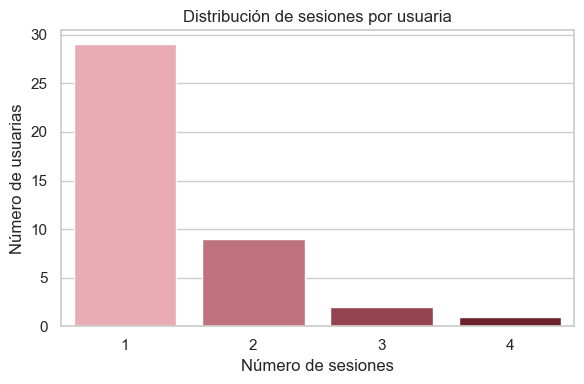

In [14]:

lookiero_palette = ['#F3A2AD', '#CA6573', '#A23645', '#791422', '#51000B']
sns.set_palette(lookiero_palette)

session_count = (
    df.groupby('user_id')
      .agg(num_sessions=('session_rank', 'max'))
      .reset_index()
)

plt.figure(figsize=(6, 4))
sns.countplot(
    x='num_sessions',
    data=session_count,
    palette=lookiero_palette
)
plt.xlabel('Número de sesiones')
plt.ylabel('Número de usuarias')
plt.title('Distribución de sesiones por usuaria')
plt.tight_layout()
plt.show()


### Revisita de secciones

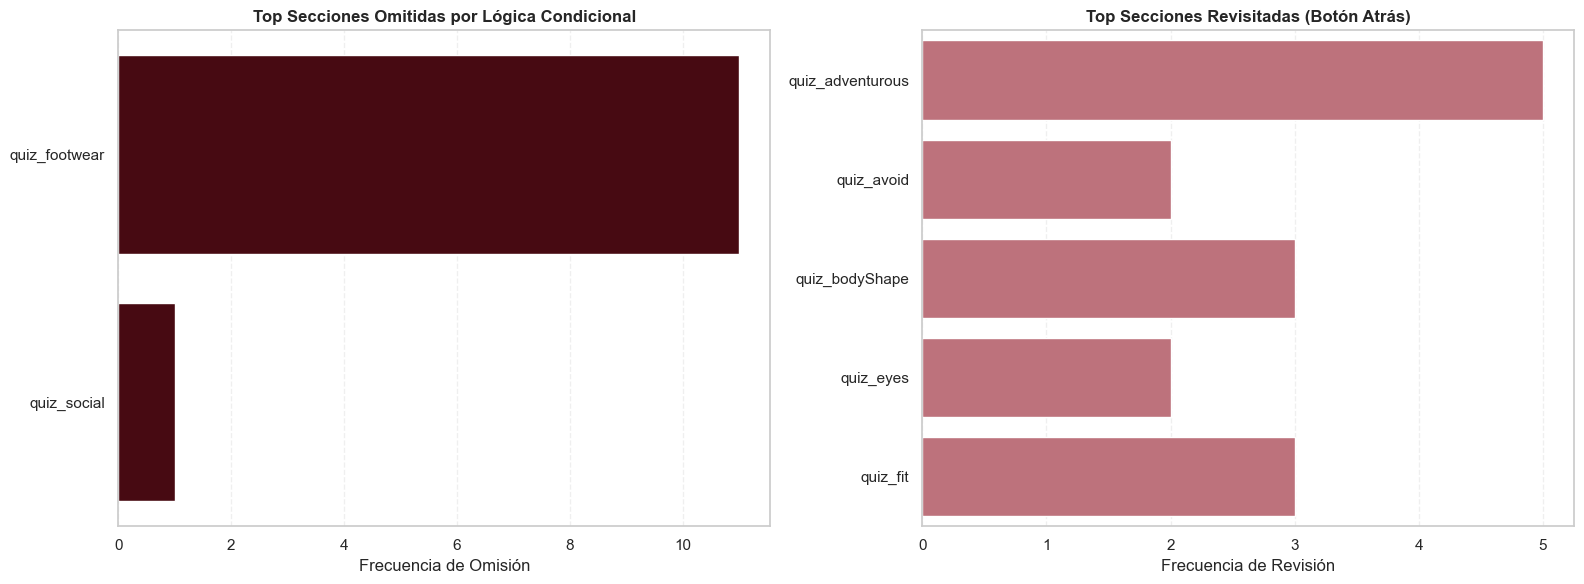

In [15]:

rank_step_inv = {v: k for k, v in step_rank.items()}

skip_events = df[df['is_skip']].copy()
skipped_sections_list = []

for _, row in skip_events.iterrows():
    prev = int(row['prev_step_number'])
    curr = int(row['step_number'])

    for step_num in range(prev + 1, curr):
        sec_name = rank_step_inv.get(step_num, f"Unknown_{step_num}")
        skipped_sections_list.append(sec_name)

skipped_df = (
    pd.Series(skipped_sections_list)
      .value_counts()
      .reset_index()
)

skipped_df.columns = ['Skipped_Section', 'Count']

backtracks_df = (
    df[df['is_backtrack']]
      .groupby('section')
      .size()
      .reset_index(name='Count')
      .rename(columns={'section': 'Revisited_Section'})
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=skipped_df.head(5),
    x='Count',
    y='Skipped_Section',
    color='#51000B',
    ax=axes[0]
)
axes[0].set_title(
    'Top Secciones Omitidas por Lógica Condicional',
    fontsize=12,
    fontweight='bold'
)
axes[0].set_xlabel('Frecuencia de Omisión')
axes[0].set_ylabel('')
axes[0].grid(axis='x', linestyle='--', alpha=0.3)

sns.barplot(
    data=backtracks_df.head(5),
    x='Count',
    y='Revisited_Section',
    color='#CA6573',
    ax=axes[1]
)
axes[1].set_title(
    'Top Secciones Revisitadas (Botón Atrás)',
    fontsize=12,
    fontweight='bold'
)
axes[1].set_xlabel('Frecuencia de Revisión')
axes[1].set_ylabel('')
axes[1].grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


### Clasificación final de estado de usuarias

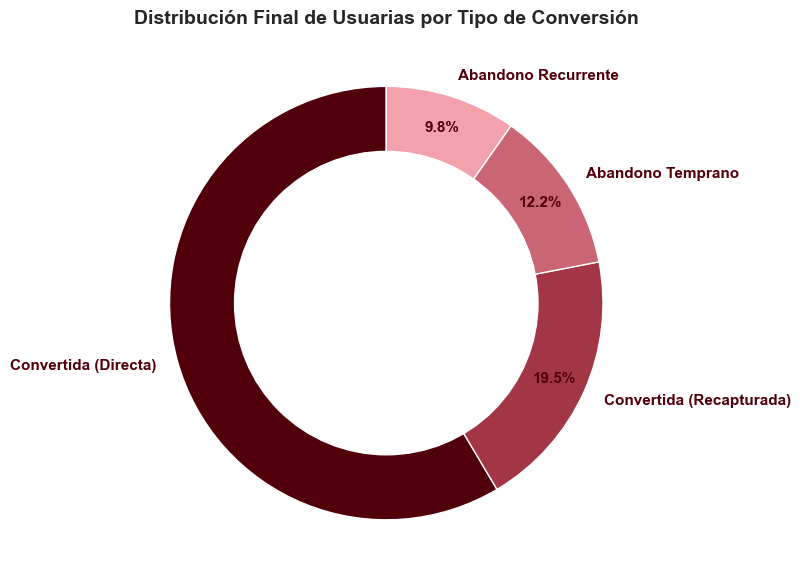

In [16]:
status_counts = user_summary['user_status'].value_counts()

plt.figure(figsize=(8, 8))
colors = ['#51000B', '#A23645', '#CA6573', '#F3A2AD'] 
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', 
        colors=colors, startangle=90, pctdistance=0.85, 
        textprops={'fontsize': 11, 'weight': 'bold', 'color': '#51000B'})

centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Distribución Final de Usuarias por Tipo de Conversión', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()